In [48]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# 检查torch版本
torch.__version__


'2.7.1+cpu'

PyTorch工作流

| **Topic** | **Module** | **Contents** |
| ----- | ----- | ----- |
| **1. 数据准备** | torch.Tensor, torch.utils.data | 数据多种多样，我们以二次函数曲线入门 |
| **2. 构建模型** | torch.nn | 在这里，我们将创建一个模型来学习数据中的模式| 
| **3. 模型训练** | Autograd, torch.optim | 选择一个损失函数、优化器并构建一个训练循环，让模型（尝试）在（训练）数据中找到模式。 |
| **4. 推理与评估** | Eval | 模型已经从数据中初步找到了合适的参数，看看这套参数在测试数据上的表现 |
| **5. 保存与加载模型** | torch.save/load | 保存/加载模型，便于后续使用 |


## 1. 数据

**数据**在机器学习中扮演重要角色，它可以是各种你能想到的数据。比如一份txt文本，excel表格，各种图像，视频和语音，还可以是化学键，生物蛋白结构等等。

* 拿到这些数据后第一件事是：将他们转化为计算机认识的数字表示；
* 然后构建合适的模型，让该模型更好的学习上面"数字"所表征的模式。

本章目的是快速了解PyTorch中常用模块的功能，因此我们生成一个已知参数的二次曲线，然后使用PyTorch构建一个模型，让这个模型去学习该曲线的参数。

In [49]:
# 设置二次函数参数
a = 0.9
b = 1.2
c = 1.6

# 生成数据
start = 0
end = 5
step = 0.05
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = a * X**2 + b * X + c

torch.manual_seed(42)
# 给数据添加些噪音
y_noise = torch.randn((100,1))
y += y_noise

X[:10], y[:10]

(tensor([[0.0000],
         [0.0500],
         [0.1000],
         [0.1500],
         [0.2000],
         [0.2500],
         [0.3000],
         [0.3500],
         [0.4000],
         [0.4500]]),
 tensor([[ 3.5269],
         [ 3.1495],
         [ 2.6297],
         [-0.3053],
         [ 2.5544],
         [ 0.7217],
         [ 1.9979],
         [ 0.5256],
         [ 1.4719],
         [ 3.9710]]))

### 划分数据

在我们开始构建模型之前，需要将上面的数据划分：

| 划分         | 用途                                                                 | 总数据量占比 | 使用频率       |
|--------------|----------------------------------------------------------------------|--------------|----------------|
| **训练集**   | 模型从这些数据中学习（就像你在学期中学习的课程材料）。                     | 约60-80%     | 总是           |
| **验证集**   | 模型在这个数据上进行调整（就像你在期末考试前参加的模拟考试）。                 | 约10-20%     | 经常，但并非总是 |
| **测试集**   | 模型在这个数据上进行评估，以测试它所学到的内容（就像你在学期末参加的期末考试）。 | 约10-20%     | 总是           |

在本例子中我们只是用训练集与测试集。

 **注意**：在处理真实世界数据时，这一步通常在项目开始时就完成（测试集应始终与其他所有数据分开）。我们希望模型从训练数据中学习，然后在测试数据上评估它，以了解它对未见样本的**泛化能力**。

In [50]:
# 将数据切分为训练/测试两部分
train_split = int(0.8 * len(X)) # 80% 训练, 20% 测试 
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

# 显示各部分数据量
print(f"训练数据量: {len(X_train)}, 测试数据量: {len(X_test)}")

训练数据量: 80, 测试数据量: 20


如上所示，我们目前训练集中包含80个样本（X_train 和 y_train），测试集中包含20个样本（X_test 和 y_test）。

我们尝试学习 X_train 和 y_train 之间的关系，然后将通过 X_test 和 y_test 来评估它所学到的关系是否符合预期。

但目前，我们的展示的数据都是一堆数字，无论在模型设计的什么阶段，将数据可视化出来都是不错的选择，能够更好的帮助我们理解数据。

那么现在就让我们创建一个函数来可视化它。

In [51]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  可视化训练/测试数据
  """
  plt.figure(figsize=(10, 7))

  # 蓝色为训练数据
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # 绿色为测试数据
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # 如果有预测数据，那么我们用红色表示
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # 画出图例便于查看
  plt.legend(prop={"size": 14})

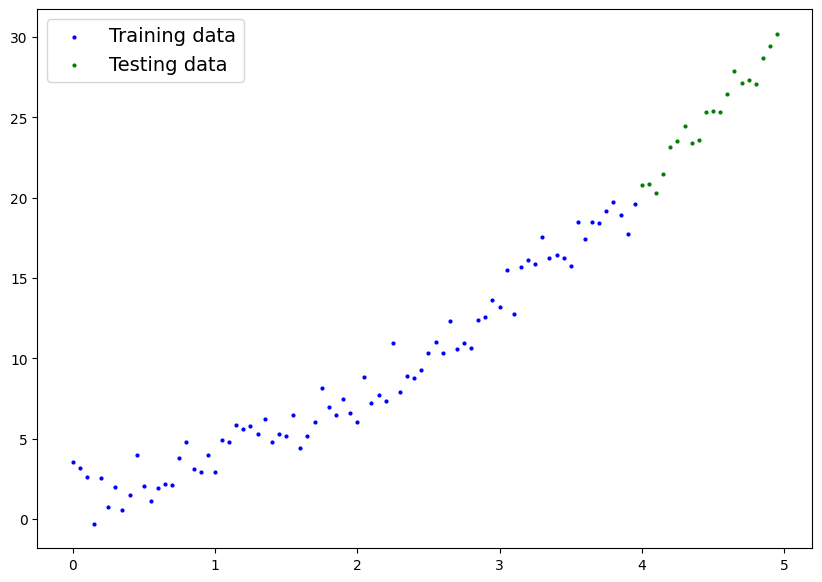

In [52]:
plot_predictions()

## 2. 构建模型

现在我们已经有了数据，让我们构建一个模型，用蓝色的点来预测绿色的点。

让我们使用PyTorch来实现一个标准的线性回归模型。

先看代码：

In [53]:
# 创建线性回归类
class LinearRegressionModel(nn.Module): # <- 大多数PyTorch功能/函数都在nn.Module中
    def __init__(self):
        super().__init__() 
        self.a = nn.Parameter(torch.randn(1,       # <- 随机初始化权重a
                              dtype=torch.float),  # <- PyTorch默认为float32格式
                              requires_grad=True)  # <- 我们需要通过梯度下降法更新这个参数，因此需要设为True

        self.b = nn.Parameter(torch.randn(1,       # <- 随机初始化权重a
                              dtype=torch.float),  # <- PyTorch默认为float32格式
                              requires_grad=True)  # <- 我们需要通过梯度下降法更新这个参数，因此需要设为True 
        
        self.c = nn.Parameter(torch.randn(1,       # <- 随机初始化权重a
                              dtype=torch.float),  # <- PyTorch默认为float32格式  
                              requires_grad=True)  # <- 我们需要通过梯度下降法更新这个参数，因此需要设为True 

    # 定义前向传播运算方式
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" 为输入数据
        return self.a * x**2 + self.b * x +self.c       # <- 线性回归公式 (y = a*x^2 + b*x + c)

上面代码中提及了`torch.nn`, `nn.Module`, `nn.Parameter`模块，以及前向推理函数`def forward()`，他们各自的作用是：

| PyTorch 模块 | 作用 |
| ----- | ----- |
| [torch.nn](https://pytorch.org/docs/stable/nn.html) | 包含计算图的所有构建块（本质上是一系列以特定方式执行的计算）。 |
| [torch.nn.Parameter](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html#parameter) | 存储可以与 `nn.Module` 一起使用的张量。如果 `requires_grad=True`，则会自动计算梯度（用于通过 [**梯度下降**](https://ml-cheatsheet.readthedocs.io/en/latest/gradient_descent.html) 更新模型参数），这通常被称为“自动微分”（autograd）。 |
| [torch.nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module) | 所有神经网络模块的基类，所有构建块都是其子类。如果你在 PyTorch 中构建神经网络，你的模型应该继承自 `nn.Module`。需要实现 `forward()` 方法。 |
| `def forward()` | 所有 `nn.Module` 子类都需要一个 `forward()` 方法，这定义了将在传递给特定 `nn.Module` 的数据上执行的计算（例如上面的线性回归公式）。 |

如果上述内容听起来很复杂，可以这样理解：在 PyTorch 神经网络中，几乎所有内容都来自 `torch.nn`，
* `nn.Module` 包含较大的构建块（层）
* `nn.Parameter` 包含较小的参数，如权重和偏置（将这些组合起来构成 `nn.Module`）
* `forward()` 告诉较大的块如何在 `nn.Module` 内部对输入（充满数据的张量）进行计算


### 实例化上面的模型

看看实例化后的模型内部参数是多少

In [54]:
# 设置种子值，便于后面随机部分复现
torch.manual_seed(42)

# 创建一个模型实例
model_0 = LinearRegressionModel()

# 查看模型中的参数
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

也可以通过`.state_dict()`查看模型参数：

In [55]:
# 列出参数名称 
model_0.state_dict()

OrderedDict([('a', tensor([0.3367])),
             ('b', tensor([0.1288])),
             ('c', tensor([0.2345]))])

注意 model_0.state_dict() 中 a, b和 c 的值是随机的浮点数，这是因为我们在上面使用 torch.randn() 对它们进行了初始化。

本质上，我们希望从随机参数开始，让模型将它们更新为最适合我们数据的参数（也就是我们在创建二次函数数据时设置的参数a,b和c）。

练习：尝试更改上面第二个单元格中的 torch.manual_seed() 的值，看看权重和偏置值会发生什么变化。

### 使用 torch.inference_mode() 进行预测

为了验证这一点，我们可以将测试数据 X_test 传递给模型，看看它对 y_test 的预测有多接近。

当我们向模型传递数据时，数据将通过模型的 forward() 方法，并使用我们定义的计算产生结果。

由于我们的模型从随机值开始，因此目前它的预测能力会很差。

In [56]:
# 看下当前模型预测的结果
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# 注意，在久torch版本中常会见到torch.no_grad()，此处和torch.inference_mode作用一样
# with torch.no_grad():
#   y_preds = model_0(X_test)

你可能已经注意到我们使用了 `torch.inference_mode()` 作为上下文管理器（这就是 `with torch.inference_mode():` 的作用）来进行预测。

顾名思义，`torch.inference_mode()` 用于在推理（进行预测）时使用模型。

`torch.inference_mode()` 关闭了一些功能（例如梯度跟踪，这是训练所必需的，但推理不需要），以加快前向传播（数据通过 forward() 方法）的速度。

**注意**：在较旧的 PyTorch 代码中，你可能会看到 `torch.no_grad()` 用于推理。尽管 `torch.inference_mode()` 和 `torch.no_grad()` 的功能相似，但 `torch.inference_mode()` 是较新的，可能更快，并且是首选。更多信息可以参考 PyTorch 的这条推文。

In [57]:
# 查看预测结果
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[6.1367],
        [6.2787],
        [6.4223],
        [6.5677],
        [6.7147],
        [6.8634],
        [7.0137],
        [7.1658],
        [7.3195],
        [7.4750],
        [7.6321],
        [7.7909],
        [7.9514],
        [8.1135],
        [8.2774],
        [8.4429],
        [8.6101],
        [8.7790],
        [8.9496],
        [9.1218]])


注意每个测试样本都有一个预测值，这是因为我们使用的数据类型。对于曲线数据，一个 X 值对应一个 y 值。

然而，机器学习模型是非常灵活的。你可以有 100 个 X 值映射到一个、两个、三个或 10 个 y 值，这完全取决于你正在处理的问题，这里为了直观和简洁，让一个x值映射到一个y值上。

同样，让我们用上面创建的 plot_predictions() 函数来可视化它们。

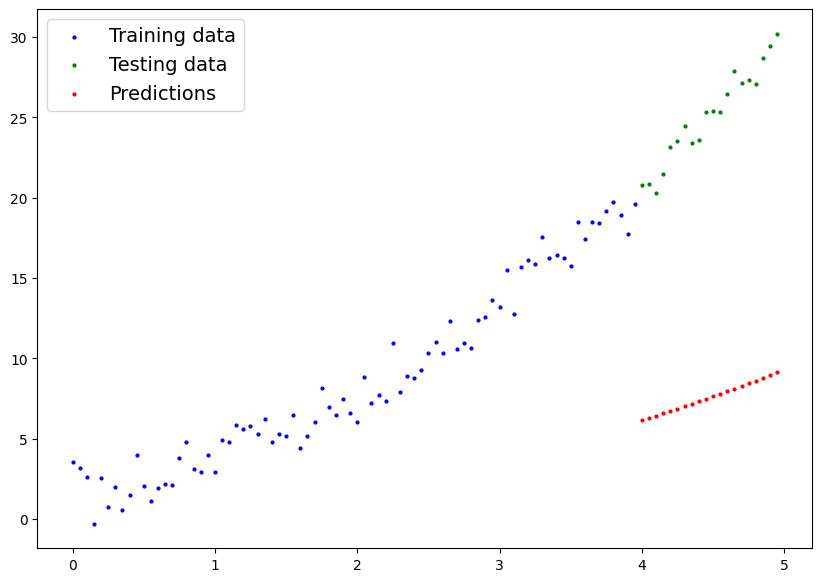

In [58]:
plot_predictions(predictions=y_preds)

In [59]:
y_test - y_preds

tensor([[14.6741],
        [14.6048],
        [13.8860],
        [14.9272],
        [16.4421],
        [16.6761],
        [17.4542],
        [16.2343],
        [16.3057],
        [17.8616],
        [17.7807],
        [17.5438],
        [18.4776],
        [19.7999],
        [18.8423],
        [18.8598],
        [18.4995],
        [19.9346],
        [20.4893],
        [21.0877]])

由于我们使用了随机数作为参数，还未进行训练，因此上面预测值（红点）和测试数据（绿点）差异很大。

接下来我们来训练这个模型。

## 3. 训练模型

目前，我们的模型正在使用随机参数来进行预测，它基本上是在瞎猜。

为了得到合适的模型，我们可以更新其内部参数（我还将参数称为模式），即我们使用 `nn.Parameter()` 和 `torch.randn()` 随机设置的 a, b 和 c 值，将它们调整为更能代表数据的值。


### 在 PyTorch 中创建损失函数和优化器

为了让我们的模型能够自动更新其参数，我们需要添加一些模块。

那就是一个**损失函数**和一个**优化器**。

它们的作用如下：

| 功能 | 作用 | 在 PyTorch 中的位置 | 常见值 |
| ----- | ----- | ----- | ----- |
| **损失函数** | 衡量模型的预测值（例如 `y_preds`）与真实标签（例如 `y_test`）之间的差异。值越低越好。 | PyTorch 在 [`torch.nn`](https://pytorch.org/docs/stable/nn.html#loss-functions) 中提供了许多内置的损失函数。 | 回归问题使用平均绝对误差（MAE）（[`torch.nn.L1Loss()`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)）。二分类问题使用二元交叉熵（[`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)）。 |
| **优化器** | 告诉模型如何更新其内部参数以最小化损失。 | 你可以从 [`torch.optim`](https://pytorch.org/docs/stable/optim.html) 中找到各种优化函数的实现。 | 随机梯度下降（[`torch.optim.SGD()`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD)）。Adam 优化器（[`torch.optim.Adam()`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)）。 |

让我们创建损失函数和优化器，以帮助改进我们的模型。

损失函数和优化器取决于你正在处理的问题类型。

然而，有一些常见的值被证明效果很好，例如 SGD（随机梯度下降）或 Adam 优化器。对于回归问题（预测一个数字）使用 MAE（平均绝对误差）损失函数，对于分类问题（预测一个类别）使用二元交叉熵损失函数。

对于我们的问题，由于我们正在预测一个数字，让我们在 PyTorch 中使用 MAE（位于 `torch.nn.L1Loss()`）作为我们的损失函数。

*平均绝对误差（MAE，在 PyTorch 中为 `torch.nn.L1Loss`）衡量两个点（预测值和标签）之间的绝对差异，然后取所有样本的平均值。*

我们将使用 SGD，`torch.optim.SGD(params, lr)`，其中：

* `params` 是你想要优化的目标模型参数（例如我们之前随机设置的 `a`, `b` 和 `c` 值）。
* `lr` 是你希望优化器更新参数的学习率，值越高意味着优化器将尝试更大的更新（这些有时可能过大，导致优化器无法工作），值越低意味着优化器将尝试更小的更新（这些有时可能过小，导致优化器需要很长时间才能找到理想的值）。学习率被认为是一个**超参数**（因为它是由机器学习工程师设置的）。学习率的常见起始值为 `0.01`

In [60]:
# 创建损失函数
loss_fn = nn.L1Loss() # MAE(L1) loss

# 创建优化器
optimizer = torch.optim.SGD(params=model_0.parameters(), # 设置优化模型中参数
                            lr=0.01)                     # learning rate (学习速率,越高越快（稳定性差） ,越低越慢（稳定性强）)

### 创建优化循环

我们已经拥有了损失函数和优化器，接下来创建一个训练循环（以及测试循环）。

训练循环涉及模型遍历训练数据，并学习`特征`和`标签`之间的关系。

测试循环涉及遍历测试数据，评估模型在训练数据上学到的模式有多好（在训练过程中，模型从未见过测试数据）。

之所以称它们为“循环”，是因为我们希望模型查看（循环遍历）每个数据集中的每个样本。

### 训练循环
对于训练循环，我们将构建以下步骤：

| 编号 | 步骤名称 | 功能描述 | 代码示例 |
| ---- | ---- | ---- | ---- |
| 1 | 前向传播 | 模型遍历所有训练数据一次，执行其`forward()`函数计算。 | `model(x_train)` |
| 2 | 计算损失 | 将模型的输出（预测值）与真实值进行比较，评估预测值的错误程度。 | `loss = loss_fn(y_pred, y_train)` |
| 3 | 清零梯度 | 将优化器的梯度清零（默认情况下梯度会累积），以便为当前训练步骤重新计算梯度。 | `optimizer.zero_grad()` |
| 4 | 对损失执行反向传播 | 计算损失相对于每个需要更新的模型参数（每个`requires_grad=True`的参数）的梯度。这被称为**反向传播**，因此称为“向后”。 | `loss.backward()` |
| 5 | 更新优化器（梯度下降） | 根据损失梯度更新`requires_grad=True`的参数，以改进模型性能。 | `optimizer.step()` |


> **注意：** 上述内容只是训练步骤的一种可能顺序或描述方式。随着经验的积累，你会发现构建 PyTorch 训练循环是非常灵活的。
>
> 关于步骤的顺序，上述顺序是推荐默认选择，但你可能会看到略有不同的顺序，但需要遵循下面经验法则：
> * 在对损失执行反向传播（`loss.backward()`）之前，先计算损失（`loss = ...`）。
> * 在计算损失相对于每个模型参数的梯度（`loss.backward()`）之前，先清零梯度（`optimizer.zero_grad()`）。
> * 在对损失执行反向传播（`loss.backward()`）之后，再执行优化器的步骤（`optimizer.step()`）。


### 测试循环

对于测试循环（评估我们的模型），典型步骤包括：

| 编号 | 步骤名称 | 功能描述 | 代码示例 |
| ---- | ---- | ---- | ---- |
| 1 | 前向传播 | 模型遍历所有测试数据一次，执行其`forward()`函数计算。 | `model(x_test)` |
| 2 | 计算损失 | 将模型的输出（预测值）与真实值进行比较，评估预测值的错误程度。 | `loss = loss_fn(y_pred, y_test)` |
| 3 | 计算评估指标（可选） | 除了损失值外，你可能还希望计算其他评估指标，例如测试集上的准确率。 | 自定义函数 |

注意，测试循环中不包含执行反向传播（`loss.backward()`）或优化器步骤（`optimizer.step()`），这是因为测试时模型的参数不会被改变，它们已经在训练阶段计算好了。在测试中，我们只关心模型前向传播的输出。

接下来训练100**epoches**, 每10 epoches评估一次。

In [61]:
torch.manual_seed(19)

# 设置epochs次数 (how many times the model will pass over the training data)
epochs = 100

# 用于保存训练/测试loss信息
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### 训练阶段

    # 设置模型为训练模式
    model_0.train()

    # 1. 在训练集上推理（会调用forward函数） 
    y_pred = model_0(X_train)

    # 2. 计算 loss (衡量预测结果和GT之间的差异)
    loss = loss_fn(y_pred, y_train)

    # 3. 清除optimizer中累计的梯度
    optimizer.zero_grad()

    # 4. Loss 反向传播
    loss.backward()

    # 5. 执行 optimizer
    optimizer.step()

    ### 测试阶段

    # 设置模型为测试模式
    model_0.eval()

    with torch.inference_mode():
      # 1. 在测试集上推理
      test_pred = model_0(X_test)

      # 2. 在测试集上计算 loss
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # 这里的type(torch.float)用于保证两者数据类型一致

      # 打印结果
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 6.5101118087768555 | MAE Test Loss: 16.368762969970703 
Epoch: 10 | MAE Train Loss: 3.2890572547912598 | MAE Test Loss: 4.868358135223389 
Epoch: 20 | MAE Train Loss: 1.2849485874176025 | MAE Test Loss: 2.616757392883301 
Epoch: 30 | MAE Train Loss: 1.2470985651016235 | MAE Test Loss: 2.7774031162261963 
Epoch: 40 | MAE Train Loss: 1.2196156978607178 | MAE Test Loss: 2.722909927368164 
Epoch: 50 | MAE Train Loss: 1.1946173906326294 | MAE Test Loss: 2.5613255500793457 
Epoch: 60 | MAE Train Loss: 1.1701158285140991 | MAE Test Loss: 2.3657305240631104 
Epoch: 70 | MAE Train Loss: 1.146031141281128 | MAE Test Loss: 2.2171854972839355 
Epoch: 80 | MAE Train Loss: 1.122664213180542 | MAE Test Loss: 2.066155195236206 
Epoch: 90 | MAE Train Loss: 1.1017720699310303 | MAE Test Loss: 1.9757473468780518 


上面打印信息显示每个epoch后loss呈下降趋势。

同样的，数值并不是那么直观，我们把他画出来看看。

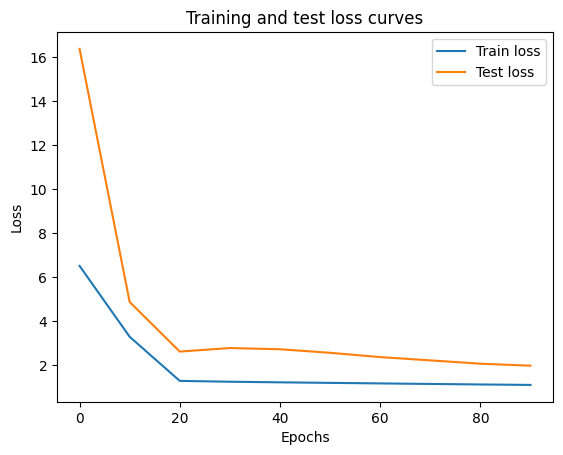

In [62]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

**损失曲线**显示了损失值随时间逐渐下降。损失是衡量你的模型有多“错误”的指标，因此越低越好。

但是，为什么损失值会下降呢？

这多亏了我们的损失函数和优化器，模型的内部参数（`a`, `b`和`c`）被更新，从而更好地反映了数据中的潜在模式。

让我们检查一下模型的[`.state_dict()`](https://pytorch.org/tutorials/recipes/recipes/what_is_state_dict.html)，看看模型的权重和偏置参数与我们最初设定的值有多接近。

In [63]:
# 看看模型学习到的参数数值是多少
print("模型学习到的a,b和c:")
print(model_0.state_dict())
print("\n我们设置的值:")
print(f"a: {a}, b: {b}, c: {c}")

模型学习到的a,b和c:
OrderedDict({'a': tensor([1.1435]), 'b': tensor([0.7193]), 'c': tensor([0.7155])})

我们设置的值:
a: 0.9, b: 1.2, c: 1.6


看起来和`a`,`b`和`c`的原始值已经有些接近了。

> **练习：** 尝试将上面的`epochs`值改为200，看看模型的损失曲线以及权重和偏置参数值会发生什么变化？

它可能永远不会完全猜出这些值（尤其是使用更复杂的数据集时），但这没关系，很多时候，用近似值也足够了。

这就是机器学习和深度学习的核心理念，**有一些理想值可以描述我们的数据**，而不是手动去计算它们，**我们可以训练一个模型来自动地找出这些值**。

## 4. 使用训练好的 PyTorch 模型进行预测（推理）

一旦你训练好了一个模型，你很可能想要用它来进行预测并用在实际使用中。

我们在上面的训练和测试代码中已经使用了，而在训练/测试循环之外进行预测的步骤是类似的。

使用 PyTorch 模型进行预测（也称为执行推理）时，有三点需要注意：

1. 将模型设置为评估模式（`model.eval()`）。
2. 使用推理模式上下文管理器进行预测（`with torch.inference_mode(): ...`）。
3. 所有预测都应在相同设备上进行（例如，数据和模型仅在 GPU 上，或者数据和模型仅在 CPU 上）。

前两点确保了在训练过程中 PyTorch 在后台使用的所有有助于计算和设置但在推理中不必要的功能都被关闭（这将导致更快的计算）。而第三点则确保你不会遇到跨设备错误。

In [64]:
# 1. 设置模型为测试模式
model_0.eval()

# 2. 设置为推理的上下文模式
with torch.inference_mode():
  # 3. 确保计算是在模型和数据位于同一设备上进行的
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
y_preds

tensor([[21.8881],
        [22.3843],
        [22.8862],
        [23.3939],
        [23.9073],
        [24.4263],
        [24.9511],
        [25.4816],
        [26.0179],
        [26.5598],
        [27.1075],
        [27.6609],
        [28.2200],
        [28.7848],
        [29.3553],
        [29.9316],
        [30.5135],
        [31.1012],
        [31.6946],
        [32.2938]])

我们依然画出结果来更直观感受差异。

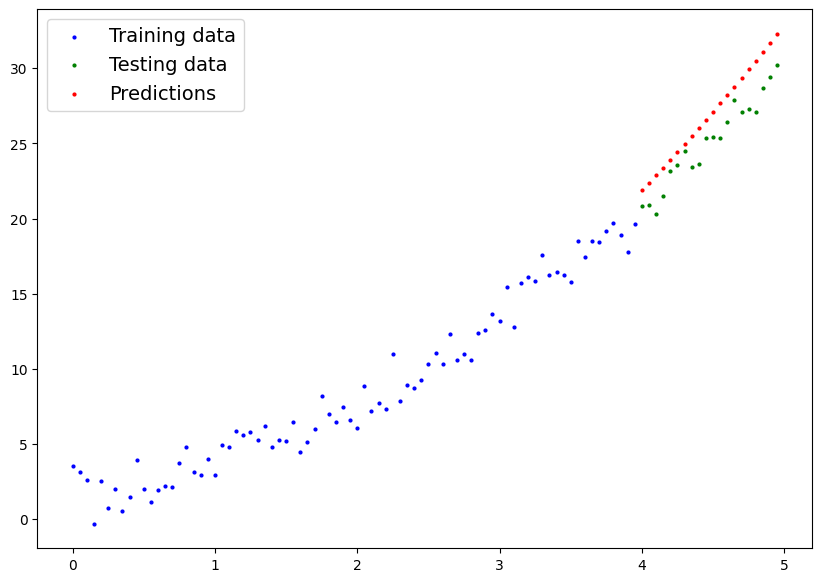

In [65]:
plot_predictions(predictions=y_preds)

看起来测试和预测的结果已经非常相近了。

至此我们已经拥有了一个效果还不错的模型，我们想把它保存下来以供后续使用。

## 5. 保存和加载 PyTorch 模型

如果你已经训练了一个 PyTorch 模型，很可能你会想要保存它并将其导出到其他地方。

比如，你可能在 Google Colab 或本地带有 GPU 的机器上训练了模型，但现在你想要将其导出到某个应用程序中，让其他人可以使用它。

或者，你可能想要保存模型的进度，稍后回来再加载它。

在 PyTorch 中保存和加载模型，有三种主要方法你应该了解（以下内容均来自 [PyTorch 保存和加载模型指南](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference)）：

| PyTorch 方法 | 功能描述 |
| ---- | ---- |
| [`torch.save`](https://pytorch.org/docs/stable/torch.html?highlight=save#torch.save) | 使用 Python 的 [`pickle`](https://docs.python.org/3/library/pickle.html) 工具将序列化对象保存到磁盘。模型、张量以及各种其他 Python 对象（如字典）都可以使用 `torch.save` 进行保存。 |
| [`torch.load`](https://pytorch.org/docs/stable/torch.html?highlight=torch%20load#torch.load) | 使用 `pickle` 的反序列化功能，将序列化的 Python 对象文件（如模型、张量或字典）加载到内存中。你还可以设置将对象加载到的设备（CPU、GPU 等）。 |
| [`torch.nn.Module.load_state_dict`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=load_state_dict#torch.nn.Module.load_state_dict) | 使用保存的 `state_dict()` 对象加载模型的参数字典（`model.state_dict()`）。 |


### 保存 PyTorch 模型的 `state_dict()`

保存和加载模型以用于推理（进行预测）的 [推荐方法](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference) 是通过保存和加载模型的 `state_dict()`。

让我们通过以下几步来看看如何做到这一点：

1. 我们将使用 Python 的 `pathlib` 模块创建一个名为 `models` 的目录来保存模型。
2. 我们将创建一个文件路径来保存模型。
3. 我们将调用 `torch.save(obj, f)`，其中 `obj` 是目标模型的 `state_dict()`，而 `f` 是保存模型的文件名。

> **注意：** PyTorch 保存的模型或对象通常以 `.pt` 或 `.pth` 结尾，例如 `saved_model_01.pth`。

In [66]:
from pathlib import Path

# 1. 创建存放模型的目录 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. 设置模型保存路径和名称 
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. 保存模型的 state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # 只保存训练得到的参数a,b,c
           f=MODEL_SAVE_PATH) 

Saving model to: models\01_pytorch_workflow_model_0.pth


### 加载保存的 PyTorch 模型的 `state_dict()`

由于我们已经在 `models/01_pytorch_workflow_model_0.pth` 位置保存了一个模型的 `state_dict()`，现在我们可以使用 `torch.nn.Module.load_state_dict(torch.load(f))` 来加载它，其中 `f` 是我们保存的模型 `state_dict()` 的文件路径。

为什么要先调用 `torch.load()` 再调用 `torch.nn.Module.load_state_dict()` 呢？

因为我们只保存了模型的 `state_dict()`，这是一个包含学习参数的字典，而不是整个模型。因此，我们首先需要用 `torch.load()` 加载 `state_dict()`，然后再将这个 `state_dict()` 传递给模型的一个新实例（该模型是 `nn.Module` 的子类）。

为什么我们不保存整个模型呢？

虽然 [保存整个模型](https://pytorch.org/tutorials/beginner/saving_loading_models.html#save-load-entire-model) 比只保存 `state_dict()` 更直观，但引用 PyTorch 文档（斜体部分是我的强调）：

> 这种方法（保存整个模型）的缺点是，序列化的数据与保存模型时使用的特定类和确切目录结构绑定……
>
> 因此，当在其他项目中使用或重构后，代码可能会以各种方式出错。

所以，我们采用了更灵活的方法，只保存和加载 `state_dict()`，这本质上是一个包含模型参数的字典。

让我们通过创建 `LinearRegressionModel()` 的另一个实例来测试一下，`LinearRegressionModel()` 是 `torch.nn.Module` 的子类，因此它将具有内置方法 `load_state_dict()`。

In [67]:
# 例化模型（参数随机）
loaded_model_0 = LinearRegressionModel()

# 载入模型参数（会从state dict中读取参数并更新到模型中）
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

现在，为了测试我们加载的模型，让我们用它来进行推理（进行预测），在测试数据上进行预测。

还记得使用 PyTorch 模型进行推理的规则吗？

如果不记得了，这里复习一下：

<details>
    <summary>PyTorch 推理规则</summary>
    <ol>
      <li>将模型设置为评估模式（<code>model.eval()</code>）。 </li>
      <li>使用推理模式上下文管理器进行预测（<code>with torch.inference_mode(): ...</code>）。 </li>
      <li>所有预测都应在相同设备上进行（例如，数据和模型仅在 GPU 上，或者数据和模型仅在 CPU 上）。</li>
    </ol> 
</details>

In [68]:
# 1. 设置为测试模式
loaded_model_0.eval()

# 2. 设置上下文为推理模式
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) # 在测试机上看看效果

验证下获得的结果和之前的模型是否一致：

In [69]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

加载的模型的预测结果与之前的模型预测结果一致（即在保存之前所做的预测）。这表明我们的模型保存和加载过程符合预期。

> **注意：** 保存和加载 PyTorch 模型还有更多方法，但我会把这些内容留给额外的课程和进一步的阅读。更多详情可以参考 [PyTorch 保存和加载模型指南](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-and-loading-models)。

## 总结



1. 使用线性回归公式（`a * X^2 + b* X + c`）创建一个直线数据集。
   * 设置新的abc, 数据点总数至少为 100 个。
   * 将数据分为 80% 的训练集和 20% 的测试集。
   * 绘制训练数据和测试数据，使其可视化。
2. 通过继承 `nn.Module` 构建一个 PyTorch 模型。
   * 内部应该有一个随机初始化的 `nn.Parameter()`，`requires_grad=True`，用于 `a`,`b`和`c`。
   * 实现 `forward()` 方法，计算你在第 1 步中用于创建数据集的线性回归函数。
   * 构建模型后，创建一个实例并检查其 `state_dict()`。
   * **注意：** 如果你想使用 `nn.Linear()` 而不是 `nn.Parameter()`，你可以。
3. 使用 `nn.L1Loss()` 和 `torch.optim.SGD(params, lr)` 分别创建一个损失函数和优化器。
   * 将优化器的学习率设置为 0.01，要优化的参数应该是你在第 2 步中创建的模型的参数。
   * 编写一个训练循环，执行适当的训练步骤，训练 500 个周期。
   * 训练循环应该每 20 个周期在测试数据集上测试模型。
4. 使用训练好的模型对测试数据进行预测。
   * 将这些预测与原始训练和测试数据进行可视化对比（**注意：** 如果你想使用非 CUDA 支持的库（如 matplotlib）进行绘图，可能需要确保预测结果不在 GPU 上）。
5. 将训练好的模型的 `state_dict()` 保存到文件中。
   * 创建你在第 2 步中创建的模型类的新实例，并将你刚刚保存的 `state_dict()` 加载到其中。
   * 使用加载的模型对测试数据进行预测，并确认它们与第 4 步中原始模型的预测结果一致。
